In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import keras 
import cv2

plt.style.use('default')
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from tensorflow.keras import layers,models,optimizers
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.applications import ResNet50V2

In [3]:
import os
import pandas as pd

train_dir = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\train'
test_dir = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\test'

def Classes_countss(path, name):
    Classes_dict = {}

    for Class in os.listdir(path):
        full_path = os.path.join(path, Class)
        if os.path.isdir(full_path):  # Make sure it's a folder
            Classes_dict[Class] = len(os.listdir(full_path))

    df = pd.DataFrame(Classes_dict, index=[name])
    return df


In [4]:
train_countss = Classes_countss(train_dir, 'Train').transpose().sort_values(by='Train', ascending=True)
test_countss = Classes_countss(test_dir, 'Test').transpose().sort_values(by='Test', ascending=True)


In [5]:
pd.concat([train_countss,test_countss],axis = 1)

,Train,Test
disgust,436,111
surprise,3171,831
angry,3995,958
fear,4097,1024
sad,4830,1247
neutral,4965,1233
happy,7215,1774


<AxesSubplot:>

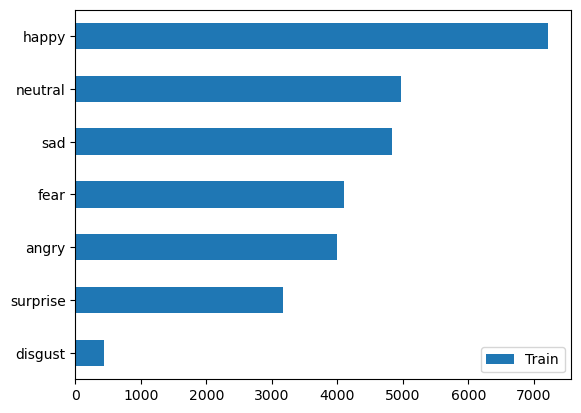

In [6]:
train_countss.plot(kind = 'barh')

<AxesSubplot:>

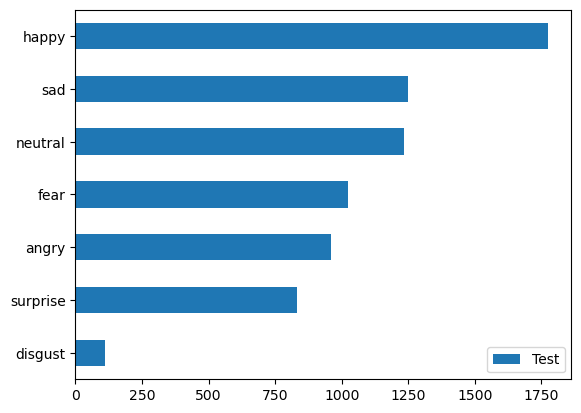

In [7]:
test_countss.plot(kind='barh')

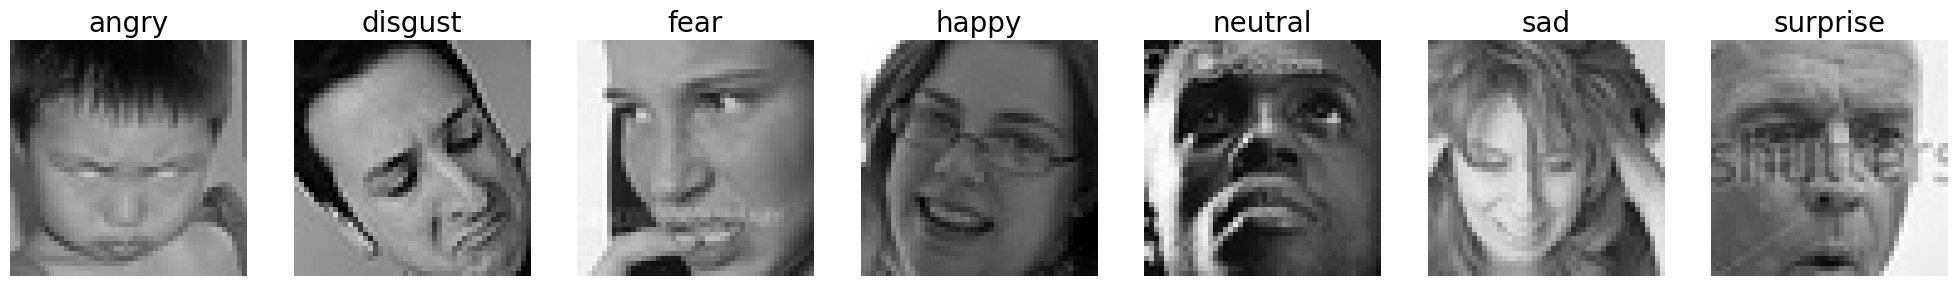

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

plt.style.use('default')
plt.figure(figsize=(25, 8))
image_count = 1
BASE_URL = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\train'

for directory in os.listdir(BASE_URL):
    dir_path = os.path.join(BASE_URL, directory)
    if os.path.isdir(dir_path):  # Ensure it's a folder
        files = os.listdir(dir_path)
        if files:  # Make sure there's at least one file
            file_path = os.path.join(dir_path, files[0])  # Take the first image
            image = cv2.imread(file_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib
            plt.subplot(1, 7, image_count)
            plt.imshow(image)
            plt.title(directory, fontsize=20)
            plt.axis('off')
            image_count += 1


###Data preprocessing

In [9]:
image_shape = 48
batch_size = 64


train_data_path = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\train'
test_data_path = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\test'



In [10]:
train_preprocessing = ImageDataGenerator(
    rescale= 1/255.,
    #data augmentation
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_preprocessing = ImageDataGenerator(
    rescale=1/255.,
)

In [11]:

train_data = train_preprocessing.flow_from_directory(
    train_data_path,
    class_mode='categorical',
    target_size=(image_shape,image_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size= batch_size,
    subset='training'
)

test_data = test_preprocessing.flow_from_directory(
    test_data_path,
    class_mode='categorical',
    target_size=(image_shape,image_shape),
    color_mode= 'rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


Bulding cnn model

In [44]:


def create_cnn_model():
    model = Sequential()

    model.add(Conv2D(32, (3,3),activation='relu',input_shape= (image_shape,image_shape,3)))
    model.add(BatchNormalization())

    model.add(Conv2D(64, (3,3), activation='relu',padding='same'))
    model.add(BatchNormalization())

    model.add(MaxPooling2D(pool_size=(32,32),padding='same'))
    model.add((Dropout(0.25)))

    #cnn2
    model.add(Conv2D(64,(3,3),activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
    model.add((BatchNormalization()))
    model.add(MaxPooling2D(pool_size=(2,2),padding='same'))
    model.add(Dropout(0.25))

    #cnn3
    model.add(Conv2D(128,(3,3),activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2),padding='same'))
    model.add(Dropout(0.25))


    #output
    model.add(Flatten())

    model.add(Dense(1024,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(512,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(256,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(128,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(64,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(32,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(7,activation='softmax'))
    
    return model
    

In [13]:
cnn_model = create_cnn_model()

cnn_model.summary()

cnn_model.compile(optimizer='adam',loss = 'categorical_crossentropy',metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 46, 46, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 46, 46, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 46, 46, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 2, 2, 64)         0         
 )                                                               
                                                        

#specifing callbacks

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

check_points_path = 'best_model.h5'
check_points = ModelCheckpoint(check_points_path, monitor='val_accuracy', save_best_only=True)

early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)

reducing_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)


In [20]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    batch_size=batch_size,
    callbacks=[reducing_lr, early_stopping, check_points]
)


Epoch 1/15
449/449 [==============================] - 473s 1s/step - loss: 2.0806 - accuracy: 0.1933 - val_loss: 1.8327 - val_accuracy: 0.2339 - lr: 0.0010
Epoch 2/15
449/449 [==============================] - 362s 808ms/step - loss: 1.8498 - accuracy: 0.2352 - val_loss: 1.7835 - val_accuracy: 0.2593 - lr: 0.0010
Epoch 3/15
449/449 [==============================] - 344s 767ms/step - loss: 1.8045 - accuracy: 0.2503 - val_loss: 1.7751 - val_accuracy: 0.2623 - lr: 0.0010
Epoch 4/15
449/449 [==============================] - 179s 398ms/step - loss: 1.7854 - accuracy: 0.2571 - val_loss: 1.7350 - val_accuracy: 0.2799 - lr: 0.0010
Epoch 5/15
449/449 [==============================] - 180s 401ms/step - loss: 1.7534 - accuracy: 0.2772 - val_loss: 1.7078 - val_accuracy: 0.3001 - lr: 0.0010
Epoch 6/15
449/449 [==============================] - 187s 416ms/step - loss: 1.7319 - accuracy: 0.2889 - val_loss: 1.6786 - val_accuracy: 0.3069 - lr: 0.0010
Epoch 7/15
449/449 [=============================

In [21]:
cnn_predictions = cnn_model.predict(test_data)

cnn_predictions = np.argmax(cnn_predictions,axis = 1)


In [22]:
test_data.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

NameError: name 'cnn_predictions' is not defined

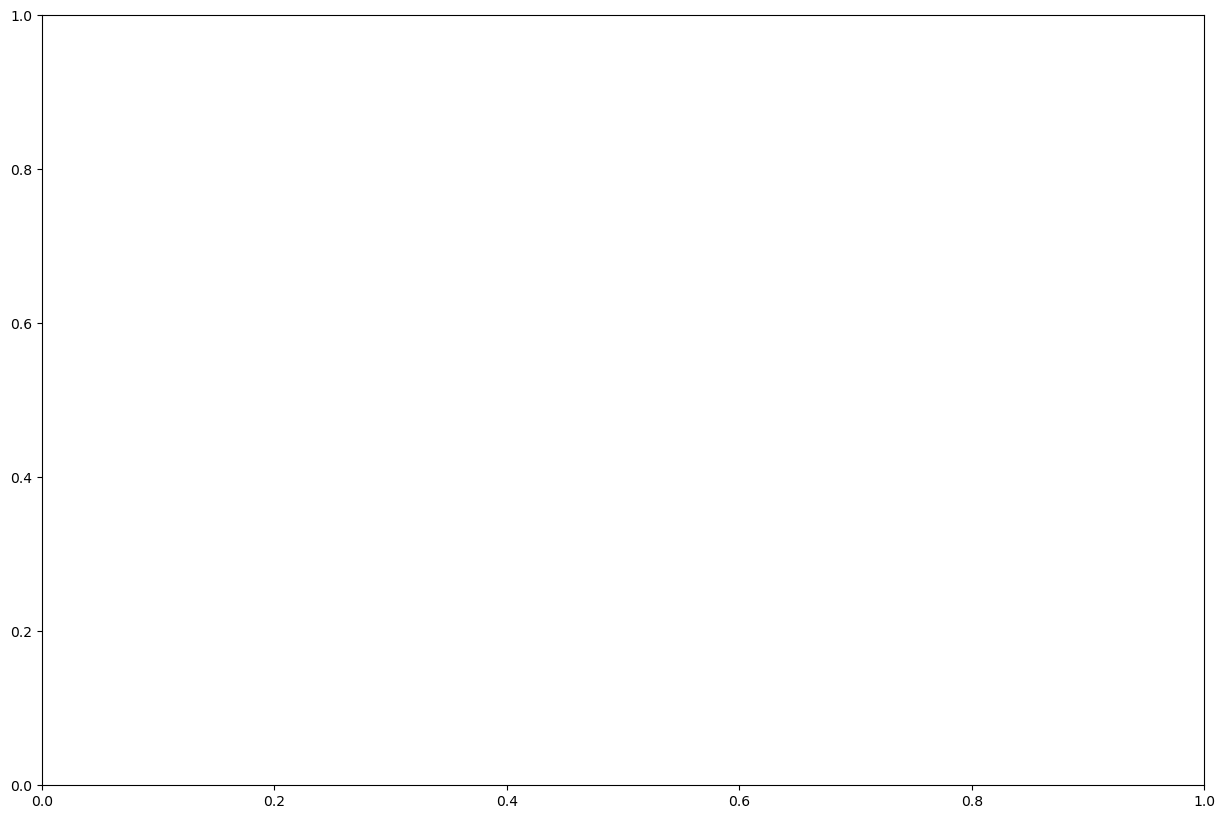

In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig,ax = plt.subplots(figsize = (15,10))
cm = confusion_matrix(test_data.labels,cnn_predictions)
sns.heatmap(cm,annot = True,fmt = 'g',ax = ax)
ax.set_xlabel('predicted labels',fontsize = 15,fontweight = 'bold')
ax.set_ylabel('true labels',fontsize = 15,fontweight = 'bold')

#music recomendations


In [110]:

music_player = pd.read_csv("C:/Users/sanjith shalu/OneDrive/Desktop/emotions-based/data_moods.csv")
print(music_player.head())

                                          name                        album  \
0                                         1999                         1999   
1                                           23                           23   
2                                     9 Crimes                            9   
3                               99 Luftballons               99 Luftballons   
4  A Boy Brushed Red Living In Black And White  They're Only Chasing Safety   

           artist                      id release_date  popularity  length  \
0          Prince  2H7PHVdQ3mXqEHXcvclTB0   1982-10-27          68  379266   
1  Blonde Redhead  4HIwL9ii9CcXpTOTzMq0MP   2007-04-16          43  318800   
2     Damien Rice  5GZEeowhvSieFDiR8fQ2im   2006-11-06          60  217946   
3            Nena  6HA97v4wEGQ5TUClRM0XLc   1984-08-21           2  233000   
4       Underoath  47IWLfIKOKhFnz1FUEUIkE   2004-01-01          60  268000   

   danceability  acousticness  energy  instrumentalness 

In [111]:
music_player.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [112]:
music_player = music_player[['name','artist','mood','popularity']]

In [113]:
music_player.head()

,name,artist,mood,popularity
0,1999,Prince,Happy,68
1,23,Blonde Redhead,Sad,43
2,9 Crimes,Damien Rice,Sad,60
3,99 Luftballons,Nena,Happy,2
4,A Boy Brushed Red Living In Black And White,Underoath,Energetic,60


In [114]:
music_player.mood.value_counts()

Sad          197
Calm         195
Energetic    154
Happy        140
Name: mood, dtype: int64

In [115]:
music_player.popularity.value_counts()

0     92
51    23
52    22
55    21
50    21
      ..
24     1
80     1
69     1
2      1
88     1
Name: popularity, Length: 83, dtype: int64

In [116]:
play = music_player[music_player['mood'] == 'Calm']
play = play.sort_values(by = 'popularity',ascending=False)
play = play[:5].reset_index(drop=True)
display(play)

,name,artist,mood,popularity
0,Lost,Annelie,Calm,64
1,Curiosity,Beau Projet,Calm,60
2,Escaping Time,Benjamin Martins,Calm,60
3,Just Look at You,369,Calm,59
4,Vague,Amaranth Cove,Calm,59


In [117]:
def Recommod_Songs(pred_class):
    if(pred_class == 'Disgust'):
        play = music_player[music_player['mood'] == 'Sad']
        play = play.sort_values(by = 'popularity',ascending=False)
        play = play[:5].reset_index(drop=True)
        display(play)
    
    if(pred_class == 'Happy' or pred_class == 'Sad'):
        play = music_player[music_player['mood'] == 'Happy']
        play = play.sort_values(by = 'popularity',ascending=False)
        play = play[:5].reset_index(drop=True)
        display(play)

    if(pred_class == 'Fear' or pred_class == 'Angry'):
        play = music_player[music_player['mood'] == 'Calm']
        play = play.sort_values(by = 'popularity',ascending=False)
        play = play[:5].reset_index(drop=True)
        display(play)
    
    if(pred_class == 'Surprise' or pred_class == 'Neutral'):
        play = music_player[music_player['mood'] == 'Energetic']
        play = play.sort_values(by = 'popularity',ascending=False)
        play = play[:5].reset_index(drop=True)
        display(play)

In [118]:
faceCascade = cv2.CascadeClassifier("C:\\Users\\sanjith shalu\\OneDrive\\Desktop\\emotions-based\\haarcascade_frontalface_default.xml")

In [119]:
def load_and_prep_image(filename,image_shape= 224):
    img = cv2.imread(filename)
    GrayImg = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(GrayImg,1.1,4)

    for x,y,w,h in faces:
        roi_GrayImg = GrayImg[y:y+h,x:x+w]
        roi_img =img[y:y+h,x:x+w]
        cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

        plt.imshow(cv2.cvtColor(img.cv2.COLOR_BGR2RGB))

        faces = faceCascade.detectMultiScale(roi_img,1.1,4)

        if len(faces)==0:
            print("no Faces Detected")
        else:
            for(ex,ey,ew,eh) in faces:
                img = roi_img[ey:ey+eh,ex:ew+ew]
    
    RGBImg = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    RGBImg = cv2.resize(RGBImg,(image_shape,image_shape))

    RGBImg = RGBImg/255.

    return RGBImg

In [123]:
def pred_and_plot(filename,class_names):
    img = load_and_prep_image(filename)

    pred = ResNet50V2.predict(np.extend_dims(img,axis = 0))

    pred_class = Emotion_Classes[pred.argmax()]

    plt.title(f"prediction:{pred_class}")
    plt.axis(False)

    Recommod_Songs(pred)

In [122]:
pred_and_plot("C:\\Users\\sanjith shalu\\OneDrive\\Desktop\\emotions-based\\datasets\\train\\fear\\Training_135069.jpg",Emotion_Classes)

AttributeError: 'function' object has no attribute 'predict'

#restnet50v2 model

In [12]:
image_shape = 224
batch_size = 64


train_data_path = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\train'
test_data_path = r'C:\Users\sanjith shalu\OneDrive\Desktop\emotions-based\datasets\test'

In [13]:
train_preprocessing = ImageDataGenerator(
    rescale= 1/255.,
    #data augmentation
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_preprocessing = ImageDataGenerator(
    rescale=1/255.,
)
train_data = train_preprocessing.flow_from_directory(
    train_data_path,
    class_mode='categorical',
    target_size=(image_shape,image_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size= batch_size,
    subset='training'
)

test_data = test_preprocessing.flow_from_directory(
    test_data_path,
    class_mode='categorical',
    target_size=(image_shape,image_shape),
    color_mode= 'rgb',
    shuffle=False,
    batch_size=batch_size
)

from tensorflow.keras.applications import ResNet50V2
RestNet50V2 = ResNet50V2(input_shape = (224,224,3),
                                                include_top = False,
                                                weights = 'imagenet')



Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [14]:
RestNet50V2.trainable = True

for layer in RestNet50V2.layers[:-50]:
    layer.trainable = False

In [15]:
def create_RestNet50V2():
    model = Sequential([RestNet50V2,
                        Dropout(.25),
                        BatchNormalization(),
                        Flatten(),
                        Dense(64,activation='relu'),
                        BatchNormalization(),
                        Dropout(.5),
                        Dense(7,activation='softmax')
                        ])
    return model

In [16]:
RestNet50V2 = create_RestNet50V2()

RestNet50V2.summary()

RestNet50V2.compile(optimizer='adam',loss = 'categorical_crossentropy',metrics= ['accuracy'])



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 dropout (Dropout)           (None, 7, 7, 2048)        0         
                                                                 
 batch_normalization (BatchN  (None, 7, 7, 2048)       8192      
 ormalization)                                                   
                                                                 
 flatten (Flatten)           (None, 100352)            0         
                                                                 
 dense (Dense)               (None, 64)                6422592   
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                        

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

check_points_path = 'best_model_RestNet50V2.h5'
check_points = ModelCheckpoint(check_points_path, monitor='val_accuracy', save_best_only=True)

early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)

reducing_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)


In [18]:
RestNet50V2_history = RestNet50V2.fit(train_data,validation_data=test_data,epochs = 1,batch_size=batch_size,
                            callbacks=[reducing_lr, early_stopping, check_points])

449/449 [==============================] - ETA: 0s - loss: 1.5497 - accuracy: 0.4687

c:\Users\nani\anaconda3\lib\site-packages\keras\engine\functional.py:1410: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  layer_config = serialize_layer_fn(layer)


449/449 [==============================] - 3836s 9s/step - loss: 1.5497 - accuracy: 0.4687 - val_loss: 1.2265 - val_accuracy: 0.5563 - lr: 0.0010


In [19]:
RestNet50V2_prediction = RestNet50V2.predict(test_data)

RestNet50V2_prediction = np.argmax(RestNet50V2_prediction,axis = 1)

Text(158.22222222222223, 0.5, 'true labels')

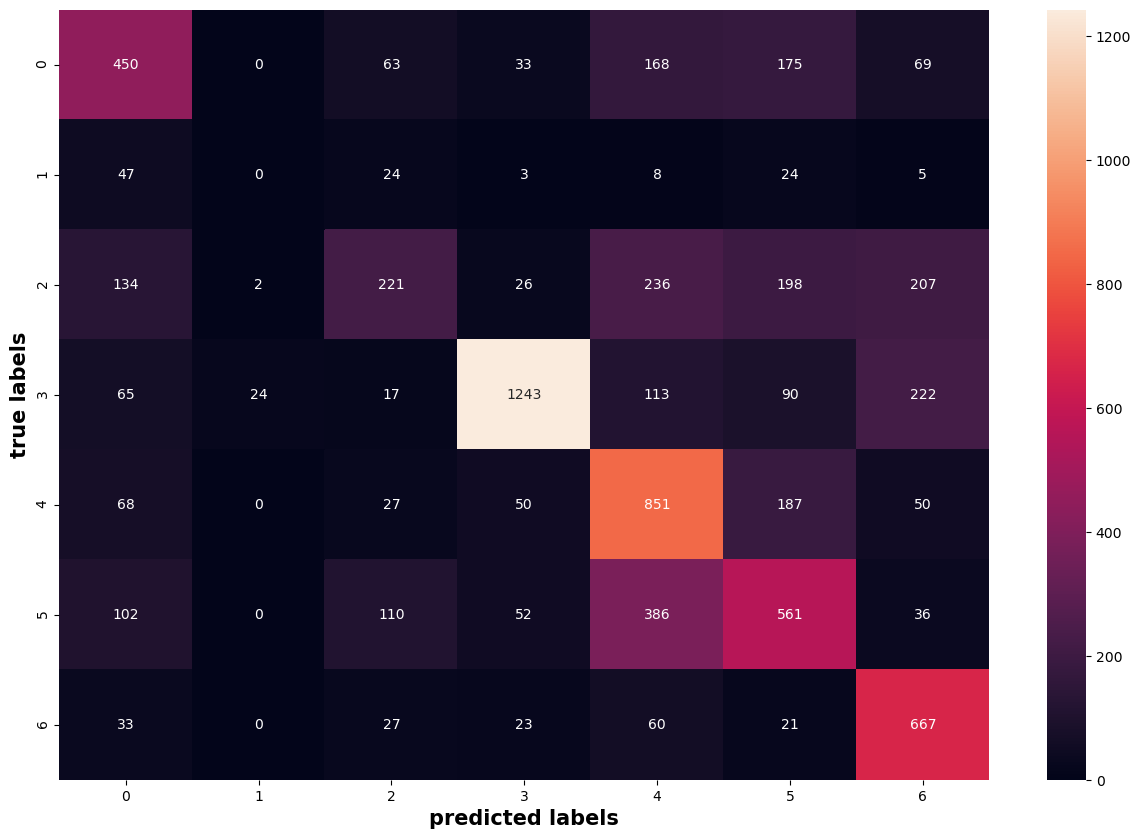

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig,ax = plt.subplots(figsize = (15,10))
cm = confusion_matrix(test_data.labels,RestNet50V2_prediction)
sns.heatmap(cm,annot = True,fmt = 'g',ax = ax)
ax.set_xlabel('predicted labels',fontsize = 15,fontweight = 'bold')
ax.set_ylabel('true labels',fontsize = 15,fontweight = 'bold')

In [91]:
Emotion_Classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [92]:
test_preprocessing = ImageDataGenerator(
    rescale = 1/255
)

test_generator = test_preprocessing.flow_from_directory(
    test_data_path,
    class_mode = 'categorical',
    target_size = (image_shape,image_shape),
    color_mode = 'rgb',
    shuffle = True,
    batch_size = batch_size,
)

Found 7178 images belonging to 7 classes.


In [102]:
RestNet50V2.save("ResNet50V2.h5")

c:\Users\nani\anaconda3\lib\site-packages\keras\engine\functional.py:1410: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  layer_config = serialize_layer_fn(layer)


In [103]:
# List of class labels (index should match your model's output order)
Emotion_Classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Load your trained model
RestNet50V2 = tf.keras.models.load_model("ResNet50V2.h5")

# batch_size = your batch size used in test_generator


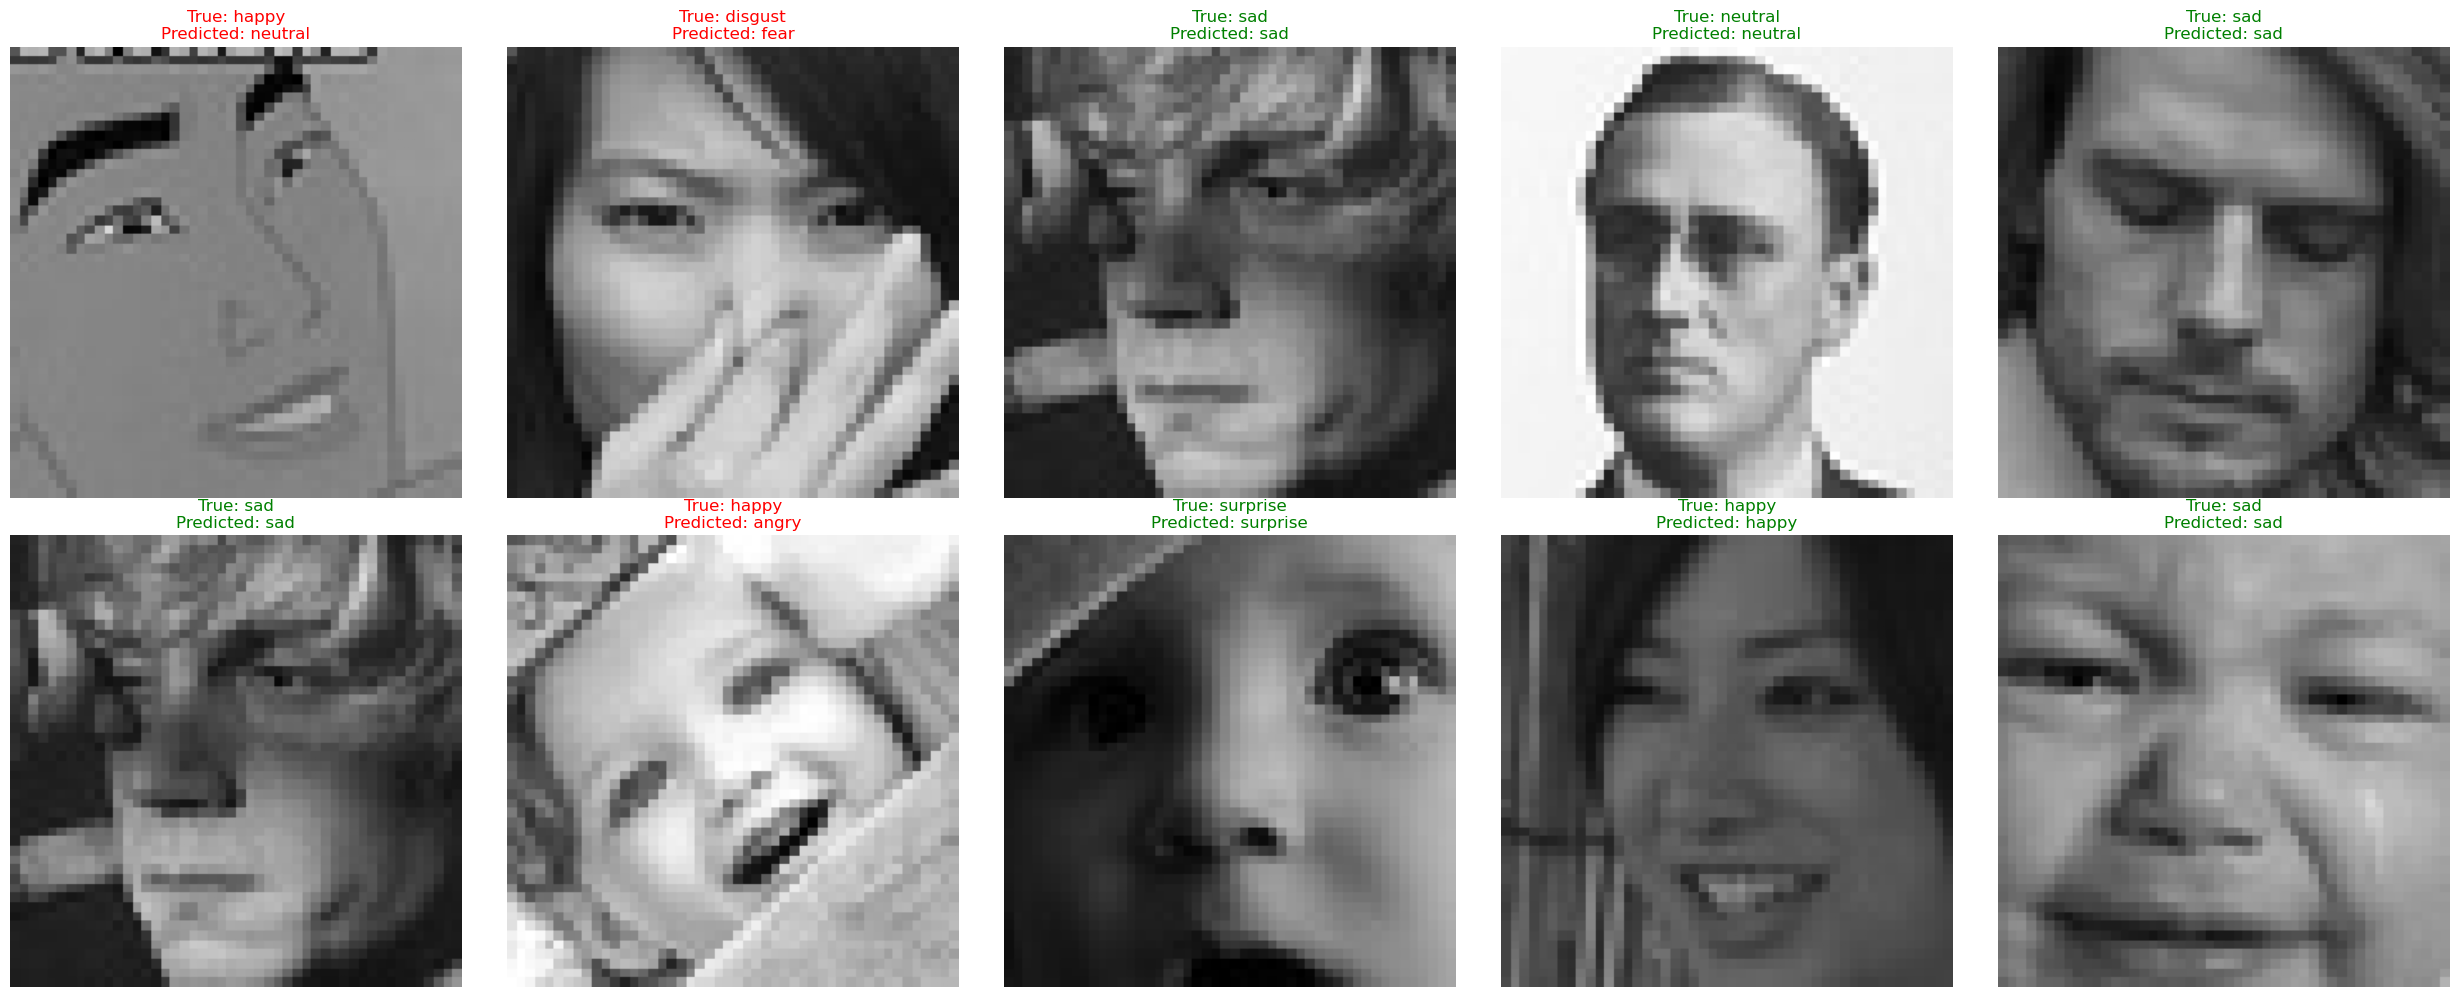

In [104]:
random_batch = np.random.randint(0, len(test_generator) - 1)
Random_Img_Index = np.random.randint(0, batch_size, 10)

fig, axis = plt.subplots(nrows=2, ncols=5, figsize=(25, 10))

for i, ax in enumerate(axis.flat):
    # Get image and true label
    Random_Img = test_generator[random_batch][0][Random_Img_Index[i]]
    Random_Img_label = np.argmax(test_generator[random_batch][1][Random_Img_Index[i]])

    # Predict using your trained model (not ResNet50V2 function)
    model_predicts = np.argmax(RestNet50V2.predict(tf.expand_dims(Random_Img, axis=0), verbose=0))

    # Show image
    ax.imshow(Random_Img)

    # Compare prediction with ground truth
    if Emotion_Classes[Random_Img_label] == Emotion_Classes[model_predicts]:
        color = 'green'
    else:
        color = 'red'

    ax.set_title(f"True: {Emotion_Classes[Random_Img_label]}\nPredicted: {Emotion_Classes[model_predicts]}", 
                 color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()


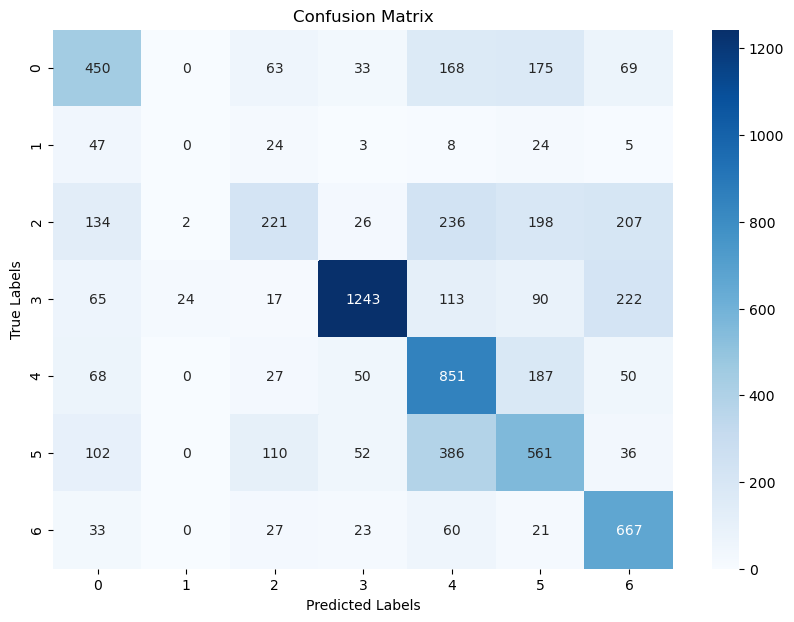

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict all test data
cnn_predictions = RestNet50V2.predict(test_data)
cnn_predictions = np.argmax(cnn_predictions, axis=1)

true_labels = test_data.classes

# Plot confusion matrix
cm = confusion_matrix(true_labels, cnn_predictions)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [105]:
def pred_and_plot(filename, model, class_names):
    img = load_and_prep_image(filename)
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_class = class_names[np.argmax(pred)]

    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False)


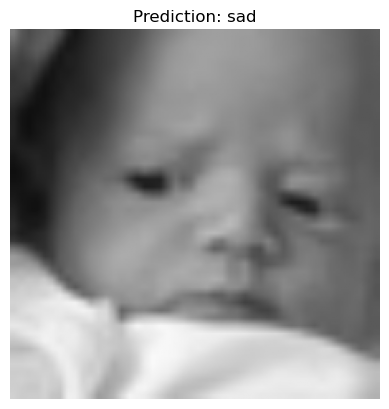

In [109]:

pred_and_plot("C:\\Users\\sanjith shalu\\OneDrive\\Desktop\\emotions-based\\datasets\\train\\fear\\Training_135069.jpg", RestNet50V2, Emotion_Classes)